In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("Housing.csv")

# Select features and target
X = df[['area']]
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
- This splits the dataset into training and testing sets.

X_train → training features (areas)

X_test → testing features (areas)

y_train → training targets (prices)

y_test → testing targets (prices)

In [3]:
from sklearn.linear_model import LinearRegression

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficient (slope) and intercept
coef = model.coef_[0]
intercept = model.intercept_

print("Coefficient (slope):", coef)
print("Intercept:", intercept)

Coefficient (slope): 425.72984193878284
Intercept: 2512254.2639593435


The coefficient tells us how much the price changes per unit increase in area.

The intercept is the baseline price when area = 0.

model.fit(X_train, y_train)
- This is where the model actually learns.

fit() means find the best line that connects area (X_train) to price (y_train).

It calculates the slope (coefficient) and intercept using the training data.

After this step, the model is trained and ready to make predictions.

model.coef_ stores the slopes of the regression line.

Since we only have one feature (area), there is just one coefficient.

model.intercept_ stores the intercept (b) of the regression line.

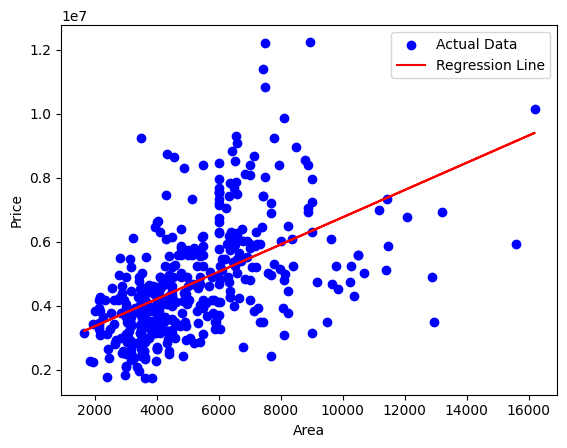

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, color='blue', label='Actual Data')
plt.plot(X_train, model.predict(X_train), color='red', label='Regression Line')
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.show()

plt.scatter(X_train, y_train, color='blue', label='Actual Data')
- Creates a scatter plot of the training data.

label='Actual Data' → adds a label so the legend can show what these points represent.

plt.plot(X_train, model.predict(X_train), color='red', label='Regression Line')
- Plots the regression line predicted by the model.

model.predict(X_train) → predicted prices for each training area.

label='Regression Line' → adds a label for the legend.

This line shows the best-fit straight line the model learned.

In [5]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Manual MSE
mse_manual = np.mean((y_test - y_pred)**2)

# Manual R²
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_manual = 1 - (ss_res/ss_tot)

# Sklearn verification
mse_sklearn = mean_squared_error(y_test, y_pred)
r2_sklearn = r2_score(y_test, y_pred)

print("Manual MSE:", mse_manual)
print("Manual R²:", r2_manual)
print("Sklearn MSE:", mse_sklearn)
print("Sklearn R²:", r2_sklearn)

Manual MSE: 3675286604768.185
Manual R²: 0.27287851871974644
Sklearn MSE: 3675286604768.185
Sklearn R²: 0.27287851871974644


from sklearn.metrics import mean_squared_error, r2_score
- Imports two evaluation metrics from scikit-learn:

mean_squared_error
- measures average squared difference between actual and predicted values.

r2_score
- measures how well the regression line explains the variance in the data.

model.predict(X_test)
- Uses the trained model to predict prices for the test set (X_test).

mse_manual = np.mean((y_test - y_pred)**2)
- Calculates Mean Squared Error (MSE) manually.

r2_manual = 1 - (ss_res/ss_tot)
- Calculates R² manually.

If R² = 1 - perfect fit.

If R² = 0 - model is no better than just predicting the mean.

If R² < 0 - model is worse than predicting the mean.

mse_sklearn = mean_squared_error(y_test, y_pred)
- Uses sklearn’s built-in function to calculate MSE.

r2_sklearn = r2_score(y_test, y_pred)
- Uses sklearn’s built-in function to calculate R².

Final Revelation:

The slope (coefficient) represents how much the predicted house price increases for each additional square unit of area.

the linear regression equation is

Price = (Coefficient × Area) + Intercept